In [17]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

EXCLUDED_DEFENSE_SYSTEMS = {"Hok/Sok", "MazEF"}
N_ITERATIONS = 500
PTUS_TO_PLOT = ["PTU-E61", "PTU-E49", "PTU-Rhi4", "PTU-Pse13", "PTU-E25", "PTU-Xan11", "PTU-N2/3"]
PALETTE = ["#e69f00", "#57b4e9", "#009e73", "#f0e443", "#0072b2", "#d55e00", "#cc79a7"]
PTU_COLORS = dict(zip(PTUS_TO_PLOT, PALETTE))

In [18]:
plt.rcParams.update(
    {
        "axes.ymargin": 0,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "legend.edgecolor": "None",
        "legend.facecolor": "None",
    }
)

In [19]:
def compute_iteration_prevalence(values: list[bool], seed: int) -> np.ndarray:
    shuffled = values.copy()
    random.Random(seed).shuffle(shuffled)
    return np.cumsum(shuffled) / np.arange(1, len(shuffled) + 1)


def compute_rarefaction_prevalence(
    values: list[bool], n_iterations: int = N_ITERATIONS
) -> dict[str, np.ndarray]:
    curves = np.array(
        [compute_iteration_prevalence(values, seed) for seed in range(n_iterations)]
    )
    return {
        "mean": curves.mean(axis=0),
        "lower": np.quantile(curves, 0.025, axis=0),
        "upper": np.quantile(curves, 0.975, axis=0),
    }


def compute_feature_curves(df: pl.DataFrame, feature: str) -> dict[str, dict[str, np.ndarray]]:
    return {
        ptu: compute_rarefaction_prevalence(
            df.filter(pl.col("ptu") == ptu).get_column(feature).to_list()
        )
        for ptu in PTUS_TO_PLOT
    }

In [20]:
ptu_df = pl.read_excel(
    "data/plsdb_imgpr_plasmid_ptu.xlsx", infer_schema_length=0
).select("plasmid_seqid", "ptu")

defense_df = pl.concat(
    [
        pl.read_excel("data/plsdb_plasmid_defense.xlsx", infer_schema_length=0),
        pl.read_excel("data/imgpr_plasmid_defense.xlsx", infer_schema_length=0),
    ]
)
defense_accessions = (
    defense_df.filter(
        ~pl.col("type").is_in(EXCLUDED_DEFENSE_SYSTEMS)
        & ~pl.col("subtype").is_in(EXCLUDED_DEFENSE_SYSTEMS)
    )
    .get_column("plasmid_seqid")
    .unique()
)

amr_df = pl.read_excel(
    "data/plsdb_imgpr_plasmid_has_amr.xlsx", infer_schema_length=0
).select(
    "plasmid_seqid",
    (pl.col("has_amr") == "true").alias("has_amr"),
)
antidef_df = pl.read_excel(
    "data/plsdb_imgpr_plasmid_has_antidef.xlsx", infer_schema_length=0
).select(
    "plasmid_seqid",
    (pl.col("has_antidef") == "true").alias("has_antidef"),
)

analysis_df = (
    ptu_df.with_columns(
        pl.col("plasmid_seqid")
        .is_in(defense_accessions.implode())
        .alias("has_defense")
    )
    .join(amr_df, on="plasmid_seqid", how="left")
    .join(antidef_df, on="plasmid_seqid", how="left")
)

In [21]:
ptu_counts = Counter(analysis_df.get_column("ptu"))
missing_ptus = sorted(set(PTUS_TO_PLOT) - ptu_counts.keys())
if missing_ptus:
    raise ValueError(f"PTUs not found in the data: {missing_ptus}")

group_sizes = {ptu: ptu_counts[ptu] for ptu in PTUS_TO_PLOT}
common_depth = min(group_sizes.values())

feature_curves = {
    feature: compute_feature_curves(analysis_df, feature)
    for feature in ("has_defense", "has_amr", "has_antidef")
}

summary_df = pl.DataFrame(
    [
        {
            "feature": feature.removeprefix("has_"),
            "ptu": ptu,
            "n_plasmids": group_sizes[ptu],
            "common_depth": common_depth,
            "prevalence": curves[ptu]["mean"][common_depth - 1],
            "ci95_low": curves[ptu]["lower"][common_depth - 1],
            "ci95_high": curves[ptu]["upper"][common_depth - 1],
        }
        for feature, curves in feature_curves.items()
        for ptu in PTUS_TO_PLOT
    ]
)
summary_df

feature,ptu,n_plasmids,common_depth,prevalence,ci95_low,ci95_high
str,str,i64,i64,f64,f64,f64
"""defense""","""PTU-E61""",64,64,1.0,1.0,1.0
"""defense""","""PTU-E49""",110,64,0.691594,0.625,0.765625
"""defense""","""PTU-Rhi4""",111,64,0.501969,0.421875,0.578125
"""defense""","""PTU-Pse13""",73,64,0.466219,0.421875,0.515625
"""defense""","""PTU-E25""",118,64,0.3384375,0.25,0.40625
…,…,…,…,…,…,…
"""antidef""","""PTU-Rhi4""",111,64,0.0,0.0,0.0
"""antidef""","""PTU-Pse13""",73,64,0.068844,0.046875,0.078125
"""antidef""","""PTU-E25""",118,64,1.0,1.0,1.0


In [22]:
def plot_rarefaction(
    curves: dict[str, dict[str, np.ndarray]],
    title: str,
    ylabel: str,
    output_paths: tuple[str, ...],
) -> None:
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

    for ptu in PTUS_TO_PLOT:
        stats = curves[ptu]
        x = np.arange(1, len(stats["mean"]) + 1)
        mean = stats["mean"]
        lower = stats["lower"]
        upper = stats["upper"]
        color = PTU_COLORS[ptu]

        ax.plot(
            x,
            mean,
            color=color,
            lw=2,
            label=f"{ptu} (n={group_sizes[ptu]})",
            zorder=5,
        )
        ax.fill_between(
            x, lower, upper, color=color, alpha=0.1, linewidth=0, zorder=4
        )

    ax.set(
        xlabel="Number of sampled plasmids",
        ylabel=ylabel,
        xlim=(1, max(group_sizes.values())),
        ylim=(0, 1),
    )
    ax.set_title(title, loc="left")
    ax.legend(loc="upper right", frameon=False)

    for path in output_paths:
        fig.savefig(path, dpi=200)
    plt.show()

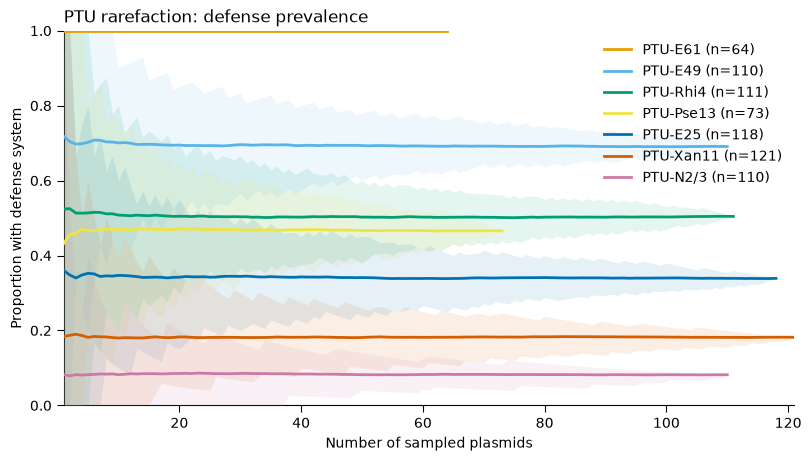

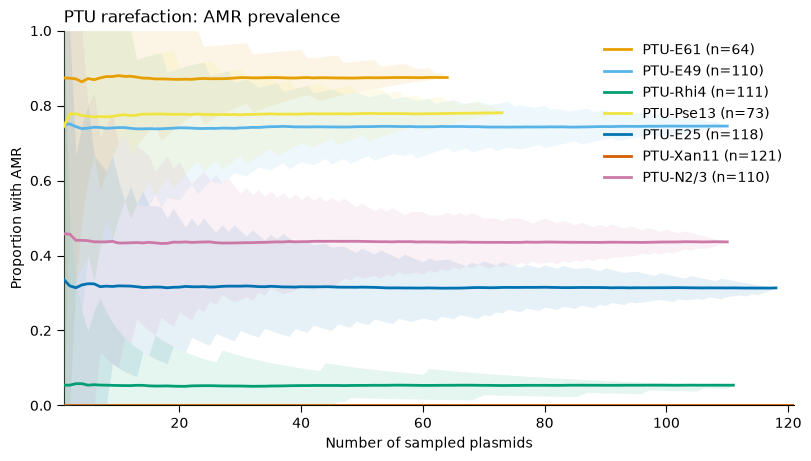

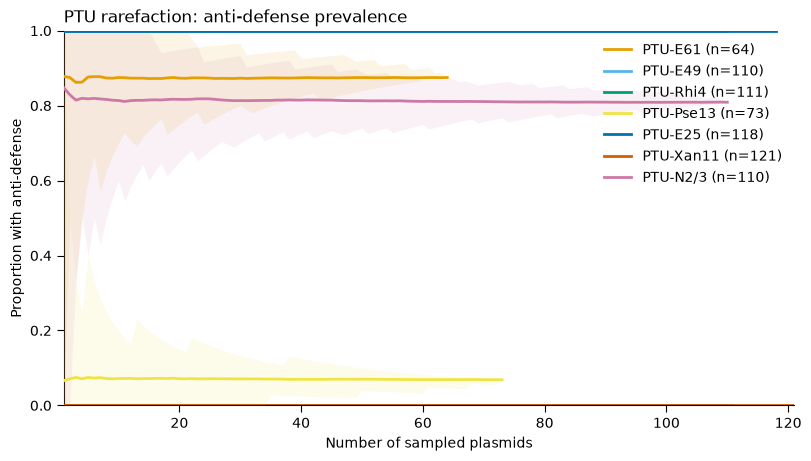

In [24]:
plot_rarefaction(
    feature_curves["has_defense"],
    "PTU rarefaction: defense prevalence",
    "Proportion with defense system",
    ("plots/figS15_A.pdf",),
)
plot_rarefaction(
    feature_curves["has_amr"],
    "PTU rarefaction: AMR prevalence",
    "Proportion with AMR",
    ("plots/figS15_B.pdf",),
)
plot_rarefaction(
    feature_curves["has_antidef"],
    "PTU rarefaction: anti-defense prevalence",
    "Proportion with anti-defense",
    ("plots/figS15_C.pdf",),
)